## FRAP analyses - interpretation

___

In [1]:
import sys
from pathlib import Path
current_dir = Path.cwd()
print("Current directory:", current_dir)
src_dir = current_dir.parents[1].joinpath('src')
sys.path.extend([str(src_dir)])
from imports import *
from frap_plotting_module import *


Current directory: /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_4_FRAP


In [2]:
apply_downsampling = False

In [3]:
results_main_folder = current_dir.joinpath('FRAP_quantification')

In [4]:
# List all immediate subfolders in results_main_folder
subfolders = [folder for folder in results_main_folder.iterdir() if folder.is_dir()]
subfolder_strings = {'utag' :  ["pNZ112_pNZ122","pNZ122_pNZ112"] ,
                     'utag_cf': ["pNZ122_244","None"],
                     'suntag': ["pNZ317_pNZ219", "pNZ317_219"],
                     'alfatag': ["pNZ165_218","None"],
                     'ha': ["pNZ035_043","None"],
                     } 

In [6]:
results_folder = current_dir.joinpath( 'Figure_4_plots')
results_folder.mkdir(exist_ok=True)

# Min–Max Normalization

We apply the following equation to normalize the values in the `mean_roi_frap_normalized` column:

$\text{normalized\_value} = \frac{\text{value} - \text{min\_val}}{\text{max\_val} - \text{min\_val}}$

In [7]:
apply_quality_check = True
drop_threshold = 0.5
apply_min_max_normalization = True  # Set to False to skip normalization

# Define your dataset types and initialize lists
list_datasets  = ['utag', 'utag_cf', 'suntag', 'alfatag', 'ha']
list_df_paths = []
list_df_FRAP = []
total_number_cells = 0
selected_field = 'mean_roi_frap' # mean_roi_frap_normalized
# Iterate over each dataset type
for dataset_type in list_datasets:
    # Loop through each subfolder (assumes 'subfolders' is defined)
    for subfolder in subfolders:
        # Check if the subfolder name matches one of the strings for this dataset type
        if (subfolder_strings[dataset_type][0] in subfolder.stem) or (subfolder_strings[dataset_type][1] in subfolder.stem):
            # Get CSV files that don't contain the unwanted substrings
            csv_files = [f for f in subfolder.glob("*.csv") 
                         if "no_roi_detected" not in f.name and "df_FRAP_fit" not in f.name]
            if csv_files:
                # Use the first matching CSV file (you may modify this logic if needed)
                selected_csv_path = csv_files[0]
                selected_df = pd.read_csv(selected_csv_path)
                # Keep only the necessary columns
                selected_df_copy = selected_df[['frame', selected_field, 'image_name']].copy()
                # Add new columns: dataset_type and subfolder_id
                selected_df_copy['dataset_type'] = dataset_type
                selected_df_copy['subfolder_id'] = subfolder.stem
                # Create a unique cell_id for each unique image (cell)
                unique_cells = selected_df_copy['image_name'].unique()
                cell_id_map = {cell: f"{subfolder.stem}_{i}" for i, cell in enumerate(unique_cells, start=1)}
                selected_df_copy['cell_id'] = selected_df_copy['image_name'].map(cell_id_map)
                # If quality check is enabled, filter cells based on drop threshold (using unnormalized data)
                if apply_quality_check:
                    filtered_df = pd.DataFrame()
                    for cell in selected_df_copy['image_name'].unique():
                        cell_data = selected_df_copy[selected_df_copy['image_name'] == cell]
                        # Extract data for the first 20 seconds
                        subset_data = cell_data[cell_data['frame'] <= 20]
                        if subset_data.empty:
                            continue
                        initial_intensity = subset_data[selected_field].iloc[0]
                        min_intensity = subset_data[selected_field].min()
                        drop = initial_intensity - min_intensity
                        # Only keep cells with a drop greater than the threshold
                        if drop > drop_threshold:
                            filtered_df = pd.concat([filtered_df, cell_data], ignore_index=True)
                        else:
                            print(f"Cell {cell} in {subfolder.stem} dropped due to insufficient drop ({drop:.2f})")
                    selected_df_copy = filtered_df.copy()
                
                # Optionally apply min–max normalization per cell (after quality check)
                if apply_min_max_normalization:
                    normalized_list = []
                    for cell in selected_df_copy['image_name'].unique():
                        cell_data = selected_df_copy[selected_df_copy['image_name'] == cell].copy()
                        min_val = cell_data[selected_field].min()
                        max_val = cell_data[selected_field].max()
                        if max_val > min_val:
                            cell_data[selected_field] = (
                                cell_data[selected_field] - min_val
                            ) / (max_val - min_val)
                        else:
                            cell_data[selected_field] = 0.0
                        normalized_list.append(cell_data)
                    selected_df_copy = pd.concat(normalized_list, ignore_index=True)
                # Append the selected data if not empty
                if not selected_df_copy.empty:
                    list_df_paths.append(selected_csv_path)
                    list_df_FRAP.append(selected_df_copy)
                    total_number_cells += selected_df_copy['cell_id'].nunique()

# Combine all extracted DataFrames into a single dataset
combined_df = pd.concat(list_df_FRAP, ignore_index=True)

# (Optional) Print out the total number of processed rows/cells
print("Combined DataFrame shape:", combined_df.shape)
print("Total number of processed cells:", total_number_cells)

Combined DataFrame shape: (35000, 6)
Total number of processed cells: 250


In [8]:

# in combined_df change all 'utag' to 'UTag', all 'suntag' to 'SunTag', and all  'alfatag' to 'ALFA-Tag'
combined_df['dataset_type'] = combined_df['dataset_type'].replace({'utag': 'UTag', 'utag_cf': r'UTag($\Delta$Cys)' , 'suntag': 'SunTag', 'alfatag': 'ALFA-tag', 'ha': 'HA'})


# save the combined dataframe as csv
combined_df.to_csv("combined_FRAP_data.csv", index=False)

In [9]:
# calculate the unique values in 'frame'
unique_frames = combined_df['frame'].unique()
print("Unique frames:", unique_frames)

Unique frames: [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  44.  49.
  54.  59.  64.  69.  74.  79.  84.  89.  94.  99. 104. 109. 114. 119.
 124. 129. 134. 139. 144. 149. 154. 159. 164. 169. 174. 179. 184. 189.
 194. 199. 204. 209. 214. 219. 224. 229. 234. 239. 244. 249. 254. 259.
 264. 269. 274. 279. 284. 289. 294. 299. 304. 309. 314. 319. 324. 329.
 334. 339. 344. 349. 354. 359. 364. 369. 374. 379. 384. 389. 394. 399.
 404. 409. 414. 419. 424. 429. 434. 439. 444. 449. 454. 459. 464. 469.
 474. 479. 484. 489. 494. 499. 504. 509. 514. 519. 524. 529. 534. 539.]


In [10]:
if apply_downsampling:
    combined_df = downsample_to_5_seconds(combined_df)

In [11]:
# Group by dataset_type and count unique cell_id values
cell_counts = combined_df.groupby('dataset_type')['cell_id'].nunique()

# Print the total number of processed cells for each dataset type
for dataset_type, count in cell_counts.items():
    print(f"{dataset_type}: {count} cells processed")

ALFA-tag: 57 cells processed
HA: 42 cells processed
SunTag: 57 cells processed
UTag: 50 cells processed
UTag($\Delta$Cys): 44 cells processed


In [12]:
combined_df

,frame,mean_roi_frap,image_name,dataset_type,subfolder_id,cell_id
0,0.0,1.000000,Cell01,UTag,results_FRAP_20231213_FRAP_pNZ112_pNZ122,results_FRAP_20231213_FRAP_pNZ112_pNZ122_1
1,1.0,0.999193,Cell01,UTag,results_FRAP_20231213_FRAP_pNZ112_pNZ122,results_FRAP_20231213_FRAP_pNZ112_pNZ122_1
2,2.0,0.978195,Cell01,UTag,results_FRAP_20231213_FRAP_pNZ112_pNZ122,results_FRAP_20231213_FRAP_pNZ112_pNZ122_1
3,3.0,0.984212,Cell01,UTag,results_FRAP_20231213_FRAP_pNZ112_pNZ122,results_FRAP_20231213_FRAP_pNZ112_pNZ122_1
4,4.0,0.980489,Cell01,UTag,results_FRAP_20231213_FRAP_pNZ112_pNZ122,results_FRAP_20231213_FRAP_pNZ112_pNZ122_1
...,...,...,...,...,...,...
34995,519.0,0.881499,FRAP 020,HA,results_FRAP_20240313_pNZ035_043_FRAP,results_FRAP_20240313_pNZ035_043_FRAP_19
34996,524.0,0.878827,FRAP 020,HA,results_FRAP_20240313_pNZ035_043_FRAP,results_FRAP_20240313_pNZ035_043_FRAP_19
34997,529.0,0.870188,FRAP 020,HA,results_FRAP_20240313_pNZ035_043_FRAP,results_FRAP_20240313_pNZ035_043_FRAP_19
34998,534.0,0.874578,FRAP 020,HA,results_FRAP_20240313_pNZ035_043_FRAP,results_FRAP_20240313_pNZ035_043_FRAP_19


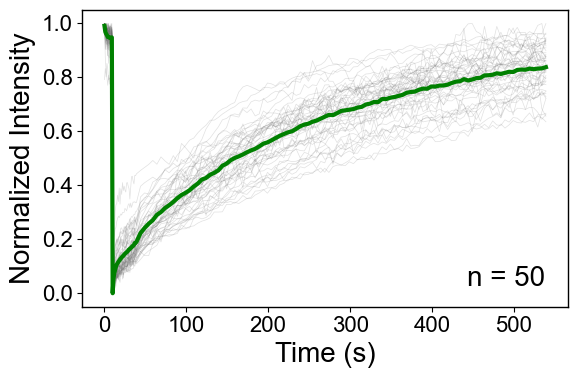

In [13]:
total_number_cells_utag, t_half_utag  = plot_FRAP_trajectories(df_list=combined_df, results_folder=results_folder, selected_dataset='UTag')

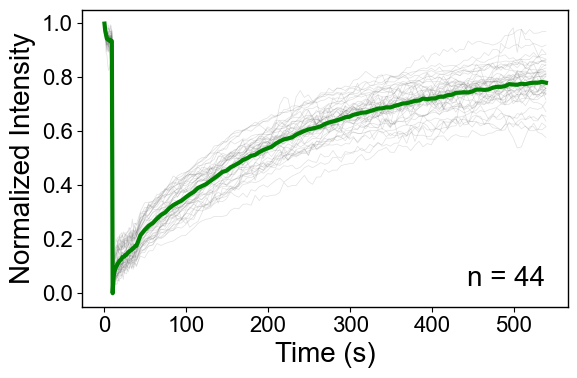

In [14]:
total_number_cells_utag_cf, t_half_utag_cf  = plot_FRAP_trajectories(df_list=combined_df, results_folder=results_folder, selected_dataset='UTag($\Delta$Cys)')

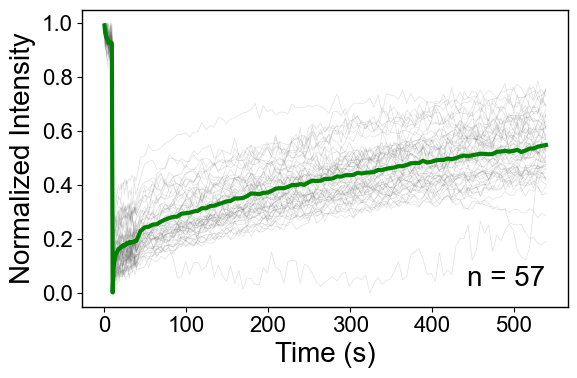

In [15]:
total_number_cells_suntag, t_half_suntag = plot_FRAP_trajectories(df_list=combined_df, results_folder=results_folder, selected_dataset='SunTag')

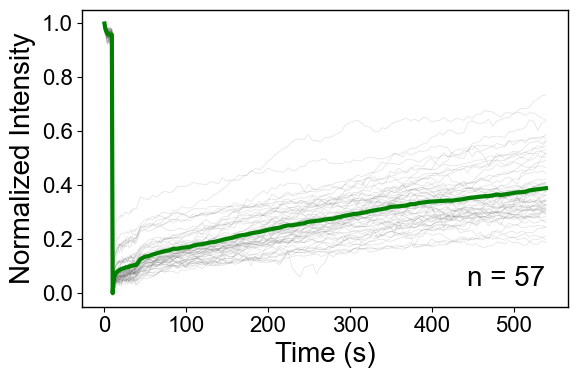

In [16]:
total_number_cells_alfatag, t_half_alfatag = plot_FRAP_trajectories(df_list=combined_df, results_folder=results_folder, selected_dataset='ALFA-tag')

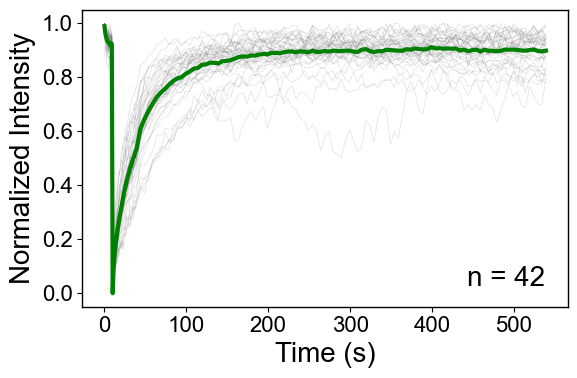

In [17]:
total_number_cells_hatag, t_half_hatag = plot_FRAP_trajectories(df_list=combined_df, results_folder=results_folder, selected_dataset='HA')

In [18]:
# for each dataset type, report the number of cells
def report_cell_count(t_half_values, dataset_type):
    print(f"{dataset_type}: number of cells = {len(t_half_values)} cells")
report_cell_count(t_half_utag, 'UTag')
report_cell_count(t_half_utag_cf, 'UTag($\Delta$Cys)')
report_cell_count(t_half_suntag, 'SunTag')
report_cell_count(t_half_alfatag, 'ALFA-tag') 
report_cell_count(t_half_hatag, 'HA')

UTag: number of cells = 50 cells
UTag($\Delta$Cys): number of cells = 44 cells
SunTag: number of cells = 57 cells
ALFA-tag: number of cells = 57 cells
HA: number of cells = 42 cells


## Plot the half times for utag and utag_cf
____

Mean t₁/₂ UTag: 176.65 s
Mean t₁/₂ UTag($\Delta$Cys): 194.07 s
Mean t₁/₂ HA: 39.24 s
SEM t₁/₂ UTag: 7.28 s
SEM t₁/₂ UTag($\Delta$Cys): 6.28 s
SEM t₁/₂ HA: 3.49 s
Comparison UTag vs UTag($\Delta$Cys): p = 0.0305
Comparison UTag vs HA: p = 0.0000
Comparison UTag($\Delta$Cys) vs HA: p = 0.0000


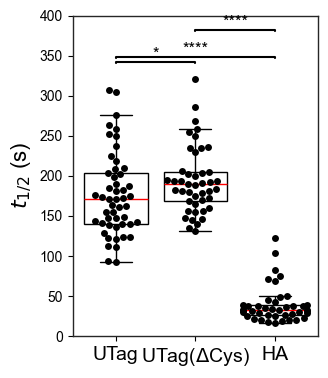

In [19]:
# Prepare t_half lists for plotting
t_half_lists = [
    t_half_utag,
    t_half_utag_cf,
    t_half_hatag,
]
names = [
    'UTag',
    'UTag($\Delta$Cys)',
    'HA',
]

# print mean values and sem
print(f"Mean t₁/₂ UTag: {np.nanmean(t_half_utag):.2f} s")
print(f"Mean t₁/₂ UTag($\Delta$Cys): {np.nanmean(t_half_utag_cf):.2f} s")
print(f"Mean t₁/₂ HA: {np.nanmean(t_half_hatag):.2f} s")
print(f"SEM t₁/₂ UTag: {stats.sem(t_half_utag, nan_policy='omit'):.2f} s")
print(f"SEM t₁/₂ UTag($\Delta$Cys): {stats.sem(t_half_utag_cf, nan_policy='omit'):.2f} s")
print(f"SEM t₁/₂ HA: {stats.sem(t_half_hatag, nan_policy='omit'):.2f} s")

# Plot the t_half boxplot with swarm
ax_t_half = plot_t_half_box_swarm(
    t_half_lists=t_half_lists,
    names=names,
    results_folder=results_folder,
    figsize=(3.5, 4),
    ylabel=r"$t_{1/2}$ (s)",
    y_min=0,
    y_max=400,
    swarm_color="black",
    tick_size=12,
    show_stats=True
)

In [20]:
# report the mean and standard deviation for each condition
def report_mean_std(t_half_list, condition_name):
    mean_t_half = np.nanmean(t_half_list)
    std_t_half = np.nanstd(t_half_list)
    n = np.count_nonzero(~np.isnan(t_half_list))
    sem_t_half = std_t_half / np.sqrt(n)
    print(f"{condition_name}: mean = {mean_t_half:.2f} s, std = {std_t_half:.2f} s, sem = {sem_t_half:.2f} s")

report_mean_std(t_half_utag, 'UTag')
report_mean_std(t_half_utag_cf, 'UTag($\Delta$Cys)')
report_mean_std(t_half_suntag, 'SunTag')
report_mean_std(t_half_alfatag, 'ALFA-tag')
report_mean_std(t_half_hatag, 'HA')

UTag: mean = 176.65 s, std = 50.98 s, sem = 7.21 s
UTag($\Delta$Cys): mean = 194.07 s, std = 41.17 s, sem = 6.21 s
SunTag: mean = 391.45 s, std = 184.70 s, sem = 24.46 s
ALFA-tag: mean = 688.14 s, std = 234.99 s, sem = 31.13 s
HA: mean = 39.24 s, std = 22.38 s, sem = 3.45 s


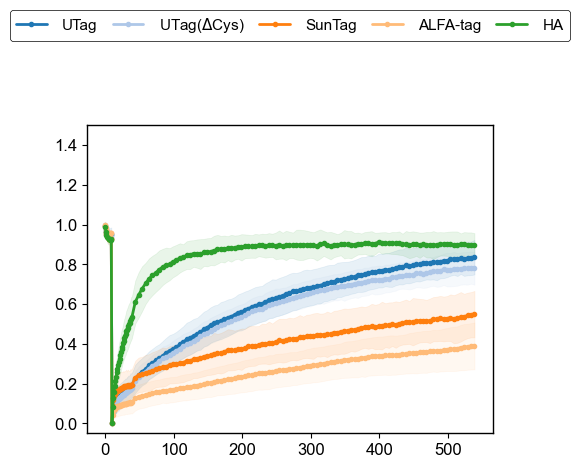

<Axes: >

In [21]:
plot_mean_trajectories_all(combined_df, 
                            ['UTag', 'UTag($\Delta$Cys)', 'SunTag', 'ALFA-tag', 'HA'],
                            results_folder=results_folder,
                            selected_field='mean_roi_frap',
                            apply_quality_check=True,
                            drop_threshold=0.8,
                            fontsize =11,
                            apply_min_max_normalization=True,
                            fig_size=(6.5,4),
                            use_sem=False)

Comparison UTag vs UTag($\Delta$Cys): p = 0.001332
Comparison UTag vs SunTag: p = 0.000000
Comparison UTag vs ALFA-tag: p = 0.000000
Comparison UTag vs HA: p = 0.000614
Comparison UTag($\Delta$Cys) vs SunTag: p = 0.000000
Comparison UTag($\Delta$Cys) vs ALFA-tag: p = 0.000000
Comparison UTag($\Delta$Cys) vs HA: p = 0.000000
Comparison SunTag vs ALFA-tag: p = 0.000000
Comparison SunTag vs HA: p = 0.000000
Comparison ALFA-tag vs HA: p = 0.000000
UTag: mean = 0.84, std = 0.09, sem = 0.01
UTag($\Delta$Cys): mean = 0.78, std = 0.08, sem = 0.01
SunTag: mean = 0.55, std = 0.12, sem = 0.02
ALFA-tag: mean = 0.39, std = 0.12, sem = 0.02
HA: mean = 0.90, std = 0.06, sem = 0.01


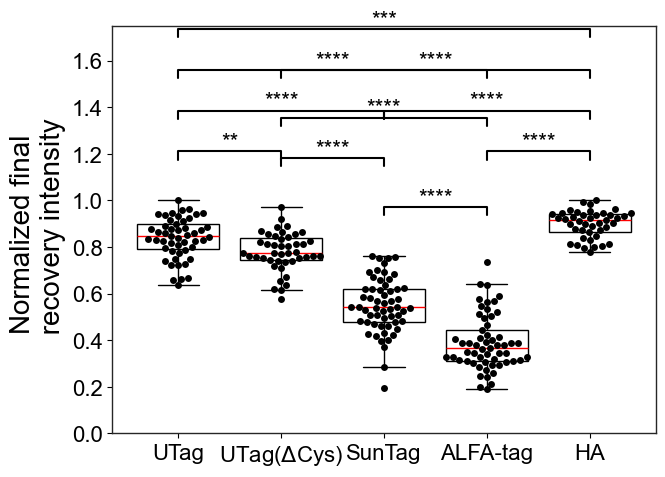

<Axes: ylabel='Normalized final \n recovery intensity'>

In [22]:
plot_box_swarm_final_values(
    df=combined_df,
    results_folder=results_folder,
    selected_field='mean_roi_frap',
    figsize=(7, 5),
    ylabel= "Normalized final \n recovery intensity",
    title="",
    y_min=0,
    y_max=1.75,
    swarm_color="black",
    tick_size=16,
    show_stats=True,
)